In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import joblib
from pathlib import Path
import time



from sklearn.model_selection import train_test_split, LearningCurveDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)



In [ ]:


df = pd.read_parquet("hf://datasets/k1tub/sentiment_dataset/data/train-00000-of-00001.parquet")

print(df.head())


e:\projects\Проекты по DS\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                                text  label        src
0  Пальто красивое, но пришло с дырой в молнии. П...      0  rureviews
1  Очень долго шел заказ,ждала к новому году,приш...      0  rureviews
2  Могу сказать одно, брюки нормальные, НО они бы...      0  rureviews
3  Доставка быстрая, меньше месяца. Заказывали ра...      0  rureviews
4  Мне не очень  понравилось это платье. Размер  ...      0  rureviews


In [3]:
df.info()
df['label'].value_counts()

# По примерам датасета: 0 - neutral/mixed, 1 - positive, 2 - negative.
id2label = {
    0: "neutral",
    1: "positive",
    2: "negative"
}

label2id = {
    "neutral": 0,
    "positive": 1,
    "negative": 2
}

class_names = [id2label[i] for i in sorted(id2label.keys())]

class_names

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290458 entries, 0 to 290457
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    290458 non-null  object
 1   label   290458 non-null  int64 
 2   src     290458 non-null  object
dtypes: int64(1), object(2)
memory usage: 6.6+ MB


['negative', 'neutral', 'positive']

In [4]:
df = df[["text", "label"]].copy()
df = df.dropna()
df["text"] = df["text"].astype(str)

df.head()

,text,label
0,"Пальто красивое, но пришло с дырой в молнии. П...",0
1,"Очень долго шел заказ,ждала к новому году,приш...",0
2,"Могу сказать одно, брюки нормальные, НО они бы...",0
3,"Доставка быстрая, меньше месяца. Заказывали ра...",0
4,Мне не очень понравилось это платье. Размер ...,0


C:\Users\Влад\AppData\Local\Temp\ipykernel_27604\3135327947.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


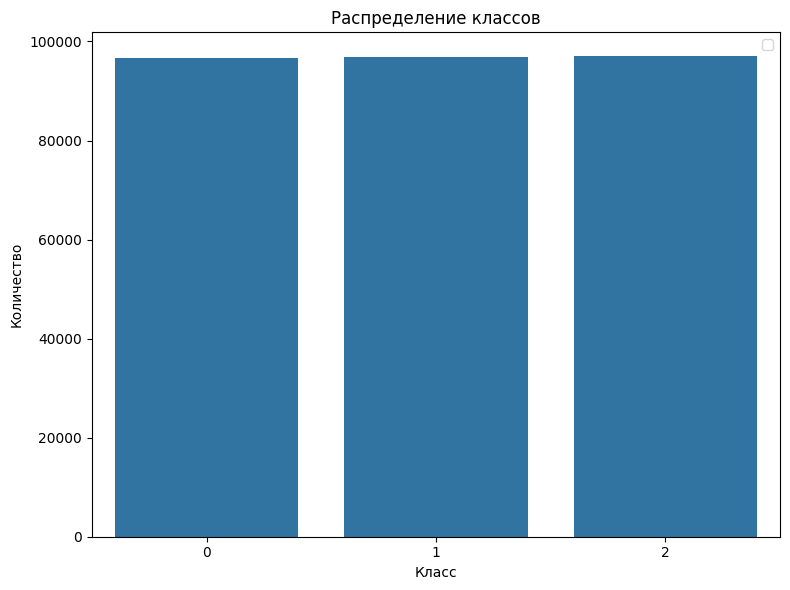

In [5]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label')
plt.title('Распределение классов')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.legend()
plt.show()

In [6]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("ё", "е")

    # Оставляем буквы, цифры и пробелы
    text = re.sub(r"[^а-яa-z0-9\s]", " ", text)
    
    # Убираем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()

    return text


In [7]:
df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,"Пальто красивое, но пришло с дырой в молнии. П...",пальто красивое но пришло с дырой в молнии про...,0
1,"Очень долго шел заказ,ждала к новому году,приш...",очень долго шел заказ ждала к новому году приш...,0
2,"Могу сказать одно, брюки нормальные, НО они бы...",могу сказать одно брюки нормальные но они были...,0
3,"Доставка быстрая, меньше месяца. Заказывали ра...",доставка быстрая меньше месяца заказывали разм...,0
4,Мне не очень понравилось это платье. Размер ...,мне не очень понравилось это платье размер l п...,0


In [8]:
X = df["clean_text"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

Train: 203320
Val: 43569
Test: 43569


In [9]:
# Пайплайн обучения модели

tfidf_logreg_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        max_features=100000,
        sublinear_tf=True
    )),

    ("logreg", LogisticRegression(
        C=2.0,
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs",
        n_jobs=-1
    ))
])

C:\Users\Влад\AppData\Local\Temp\ipykernel_27604\2203439622.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


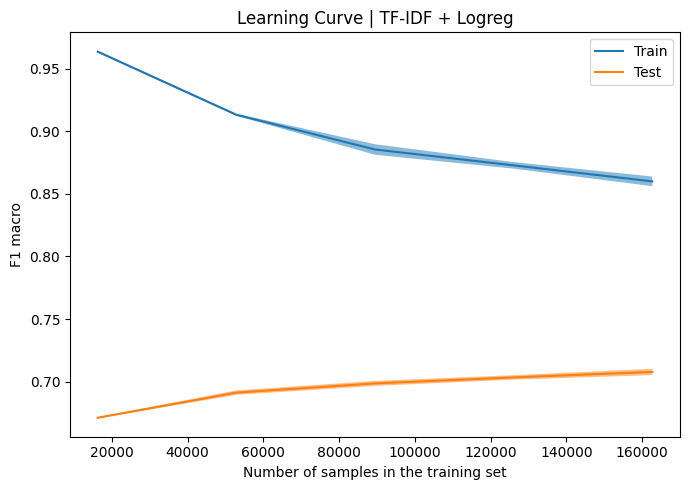

In [10]:


l_start = time.time()
tfidf_logreg_pipe.fit(X_train, y_train)    
l_end = time.time()


fig, ax = plt.subplots(figsize=(7, 5))
LearningCurveDisplay.from_estimator(
    tfidf_logreg_pipe,
    X_train,
    y_train,
    scoring="f1_macro",
    n_jobs=-1,
    ax=ax
    )

ax.set_title('Learning Curve | TF-IDF + Logreg')
fig.tight_layout()
fig.show()

In [11]:
val_preds = tfidf_logreg_pipe.predict(X_val)

val_acc = round(accuracy_score(y_val, val_preds), 3)
val_macro_f1 = round(f1_score(y_val, val_preds, average="macro"), 3)

print(f"Validation accuracy: {val_acc}")
print(f"Validation macro-F1: {val_macro_f1}")

Validation accuracy: 0.715
Validation macro-F1: 0.716


In [12]:
print(classification_report(
    y_val,
    val_preds,
    labels=[0, 1, 2],
    target_names=class_names
))

              precision    recall  f1-score   support

    negative       0.61      0.62      0.61     14488
     neutral       0.82      0.81      0.82     14532
    positive       0.72      0.72      0.72     14549

    accuracy                           0.72     43569
   macro avg       0.72      0.72      0.72     43569
weighted avg       0.72      0.72      0.72     43569



In [13]:
test_preds = tfidf_logreg_pipe.predict(X_test)

test_accuracy = accuracy_score(y_test, test_preds)
test_f1_macro = f1_score(y_test, test_preds, average="macro")

print(f"Test accuracy: {round(test_accuracy, 4)}")
print(f"Test macro-F1: {round(test_f1_macro, 4)}")

Test accuracy: 0.713
Test macro-F1: 0.7132


In [14]:
print(classification_report(
    y_test,
    test_preds,
    labels=[0, 1, 2],
    target_names=class_names
))

              precision    recall  f1-score   support

    negative       0.61      0.61      0.61     14489
     neutral       0.82      0.81      0.82     14531
    positive       0.71      0.71      0.71     14549

    accuracy                           0.71     43569
   macro avg       0.71      0.71      0.71     43569
weighted avg       0.71      0.71      0.71     43569



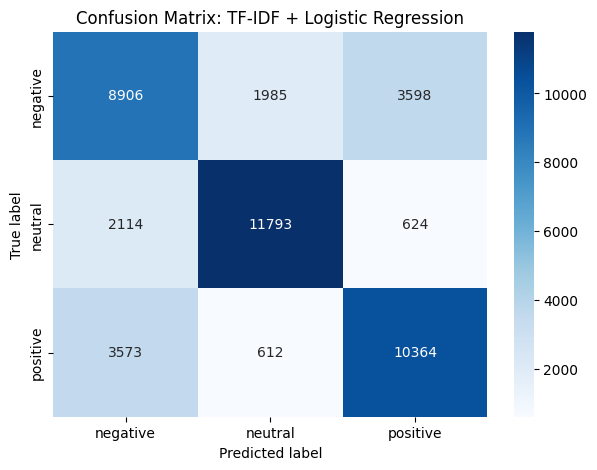

In [15]:
cm = confusion_matrix(
    y_test,
    test_preds,
    labels=[0, 1, 2]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: TF-IDF + Logistic Regression")
plt.show()

In [16]:
def predict_review(text):
    clean = clean_text(text)
    
    pred_id = tfidf_logreg_pipe.predict([clean])[0]
    pred_label = id2label[pred_id]
    
    probs = tfidf_logreg_pipe.predict_proba([clean])[0]
    
    result = {
        "text": text,
        "clean_text": clean,
        "predicted_class_id": int(pred_id),
        "predicted_class": pred_label,
        "probabilities": {
            id2label[class_id]: float(probs[i])
            for i, class_id in enumerate(tfidf_logreg_pipe.classes_)
        }
    }
    
    return result

['models\\id2label.pkl']